<a href="https://colab.research.google.com/github/Dennisogaka/Housing-Price-Prediction-ML/blob/main/housing_price_prediction_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#Load Data

from sklearn.datasets import fetch_california_housing

data=fetch_california_housing()

In [3]:
data.DESCR

print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
#Split Data

from sklearn.model_selection import train_test_split
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [5]:
## 1. Random Forest Regressor Model Training

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Create pipeline
rp = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train Model
rp.fit(X_train, y_train)

#Prediction
y_pred=rp.predict(X_test)

rp_mae=mean_absolute_error(y_test, y_pred)
rp_r2=r2_score(y_test,y_pred)

print("MAE is", rp_mae)
print("R2 is", rp_r2)

MAE is 0.33226968667635676
R2 is 0.8044394229176284


In [6]:
## 2.XGBoost Model Training

import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Create pipeline
px = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

# Train Model
px.fit(X_train, y_train)

# Prediction
XG_pred = px.predict(X_test)


px_mae=mean_absolute_error(y_test, XG_pred)
px_r2=r2_score(y_test,XG_pred)

print(px_mae)
print(px_r2)

0.32913292291062285
0.820303052430378


In [7]:
## 3. Linear Regression Model Training

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

#Create pipeline
pl = Pipeline([
    ('scaler', StandardScaler()),       # Normalizes data (Mean=0, Var=1)
    ('regressor', LinearRegression())   # The mathematical model
])

# Train model
pl.fit(X_train, y_train)

# Predictions
lr_pred = pl.predict(X_test)

pl_mae=mean_absolute_error(y_test, lr_pred)
pl_r2=r2_score(y_test,lr_pred)

print(pl_mae)
print(pl_r2)

0.5272474538305952
0.5957702326061665


In [8]:
# Extracting Coefficients from pipeline(Linear Regression)
import pandas as pd

coefficients = pl.named_steps['regressor'].coef_
feature_names = data.feature_names


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Insights (Coefficients):")
print(importance_df)

# Positive coefficients are positively related to price changes: An increase means price increase.
# Negative coefficients are negatively related to price changes: An increase means price decrease.


Model Insights (Coefficients):
      Feature  Coefficient
0      MedInc     0.849222
3   AveBedrms     0.348410
1    HouseAge     0.122119
4  Population    -0.000884
5    AveOccup    -0.041698
2    AveRooms    -0.299558
7   Longitude    -0.868617
6    Latitude    -0.893856


In [9]:
# Model Comparison

import pandas as pd

results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [pl_r2, rp_r2, px_r2],
    'MAE': [pl_mae, rp_mae, px_mae]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

#The best model is XGBoost

               Model  R2 Score       MAE
0  Linear Regression  0.595770  0.527247
1      Random Forest  0.804439  0.332270
2            XGBoost  0.820303  0.329133


In [10]:
#Hyperparameter (helps in model tuning)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

# Searching the best combination
grid_search = GridSearchCV(px, param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


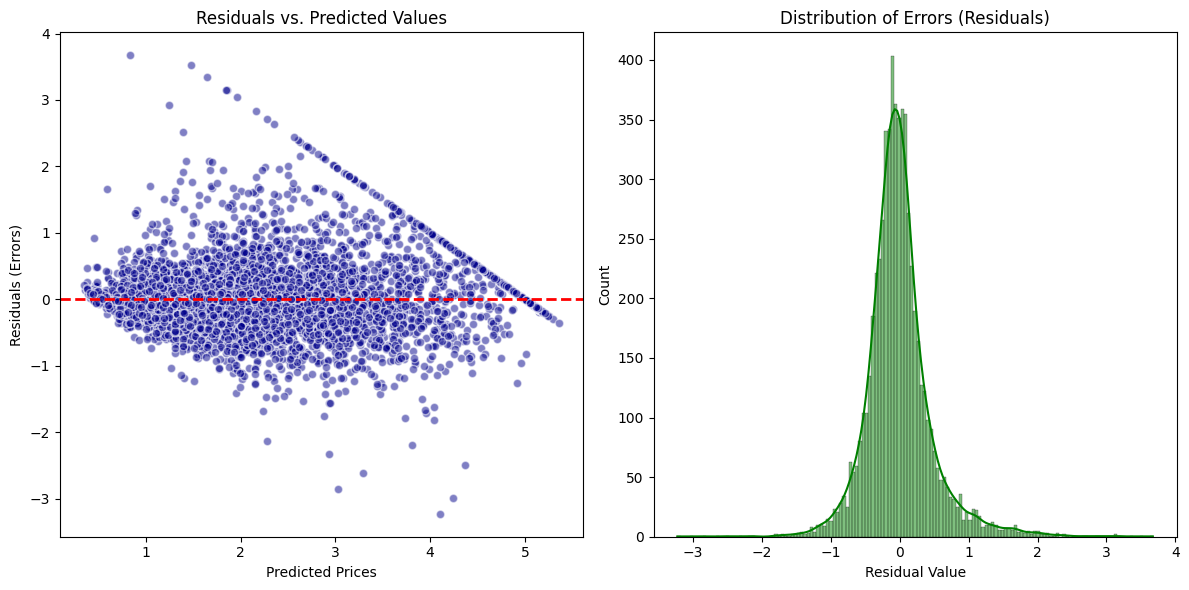

In [11]:
#Residual Analysis (Checking for Blind Spots)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate residuals (Actual - Predicted)
XG_pred = px.predict(X_test)
residuals = y_test - XG_pred

# 2. Create the plot
plt.figure(figsize=(12, 6))

# Scatter plot of residuals
plt.subplot(1, 2, 1)
plt.scatter(XG_pred, residuals, alpha=0.5, color='darkblue', edgecolors='white')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Errors)')
plt.title('Residuals vs. Predicted Values')

# Distribution of residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Errors (Residuals)')
plt.xlabel('Residual Value')

plt.tight_layout()
plt.show()

In [12]:
# dataframe to inspect the largest errors
analysis_df = pd.DataFrame({'Actual': y_test, 'Predicted': XG_pred, 'Error': residuals})
biggest_misses = analysis_df.iloc[analysis_df['Error'].abs().argsort()[-5:]]

print("Top 5 houses where the model was most wrong:")
print(biggest_misses)

Top 5 houses where the model was most wrong:
       Actual  Predicted     Error
4975  5.00001   1.843755  3.156255
4479  0.87500   4.101763 -3.226763
1649  5.00001   1.648288  3.351722
1140  5.00001   1.474814  3.525196
3710  4.50000   0.826944  3.673056


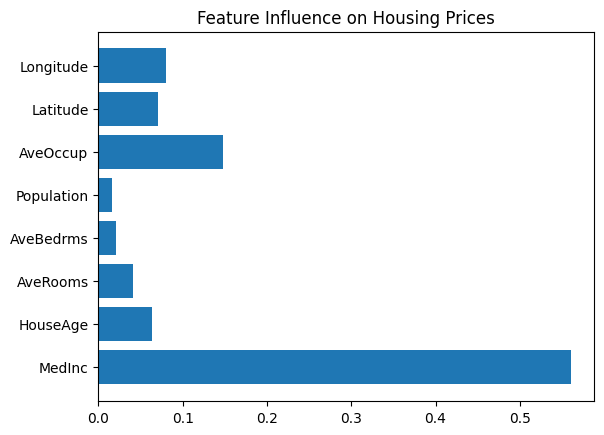

In [15]:
# Feature importance from XGBoost

import matplotlib.pyplot as plt

importance = px.named_steps['model'].feature_importances_
plt.barh(data.feature_names, importance)
plt.title("Feature Influence on Housing Prices")
plt.show()